__Markus Mulvihill__

__Last updated March 2026__

# Necessary Packages and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

# Setup
## Patient Cohort
+ 100 patients
+ Simulation over 60 hours
+ Initial $BG$ (mmol/L) is chosen from a log normal distribution of $\mu = 7.6$ and $\sigma=1.3$
+ Initial $Q$ and $I$ is 15 mu/L
+ Inital $P1$ and $P2$ is assumed to be 0 mmol/L
+ $\,SI$ for the patients is constant at $2 \cdot 10^{-4}$
+ $u_{ex}(t) = 75 \cdot e^{-\left(\frac{\log(2)}{300}\right) \cdot \left((t + 120) \mod (300)\right)}$ (mU/min)
+ $\,PN(t) = e^{-\left(\frac{\log(2)}{300}\right) \cdot \left(t \mod (300)\right)}$ (mmol/min)
+ $D(t) = 0.24$ (mmol/min)
+ True dynamics are derived from the ICING model with time steps $\,dt=1$ min
+ Blood Glucose measurements occur every 2 hours that contain Gaussian measurement noise $N(0,0.25^2)$

## State Estimators
+ State Variables are $\dot{\,BG}$, $\dot{Q}$, $\dot{I}$, $\dot{\,P1}$, $\dot{\,P2}$, $u_{en}$, $\,SI$ 
+ The initial states for all patients are assigned as $\begin{bmatrix} 7.6 & 15 & 15 & 0 & 0 & k_1 e^{-\frac{k_2}{k_3}15} & 2.1 \cdot 10^{-4} \end{bmatrix}$
+ Process Noise is $\text{diag} \left( \begin{bmatrix} \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & 0 & \frac{1e^{-12}}{120} \end{bmatrix} \right)$
+ Initial states for each particle is sampled from a Gaussian distribution with a mean of the initial state and variance of the process noise

# Experiment
+ The time to run the state estimator and the accuracy of the $BG$ estimate will be saved
+ Particle Filters of sizes $N = \begin{bmatrix}  100 & 200 & 300 & 400 & 500 & 1000 & 1500 & 3000 & 5000 \end{bmatrix}$ will be used

In [4]:
try:
    with open('../scripts/variables/G_ests.pkl', 'rb') as f:
        G_ests = pickle.load(f)
    with open('../scripts/variables/G_errors.pkl', 'rb') as f:
        G_errors = pickle.load(f)
    with open('../scripts/variables/filters_time_run.pkl', 'rb') as f:
        filters_time_run = pickle.load(f)
    with open('../scripts/variables/Cohorts.pkl', 'rb') as f:
        Cohorts = pickle.load(f)
    print('Loading variables from previous run')
except Exception:
    print("Can not find results from filter_fs_analysis.py file")

Loading variables from previous run


In [7]:
idx = 0 # dt = 1 min
G_est = G_ests[idx]
G_error = G_errors[idx]
time_run = filters_time_run[idx]

# Plot Results

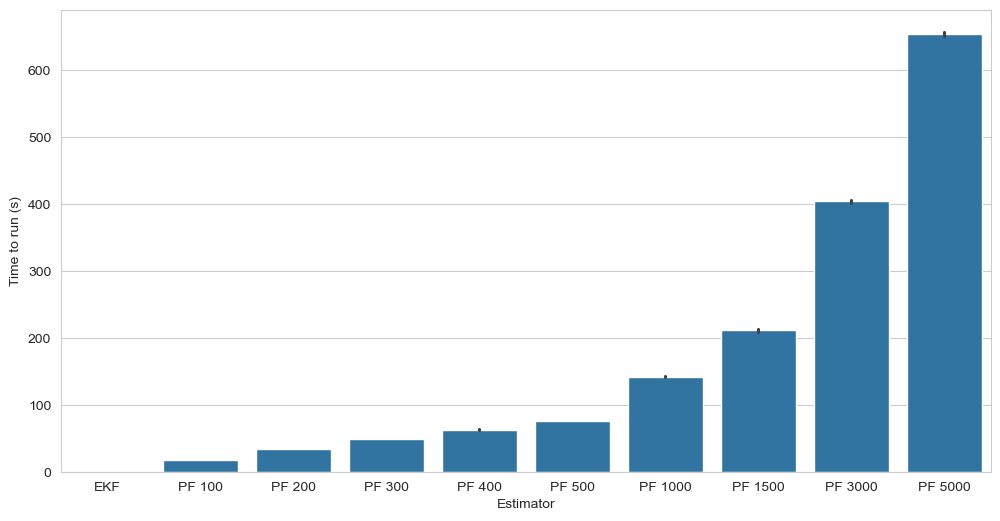

In [24]:
mean_time_run = np.average(time_run, axis=0)
filters = ["EKF"]
num_particles = np.asarray([100, 200, 300, 400, 500, 1000, 1500, 3000, 5000])
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_run, columns=filters).melt(var_name='Estimator', value_name='Time to run (s)')

fig, ax = plt.subplots(figsize=(12,6))
sns.set_style("whitegrid") 
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax);

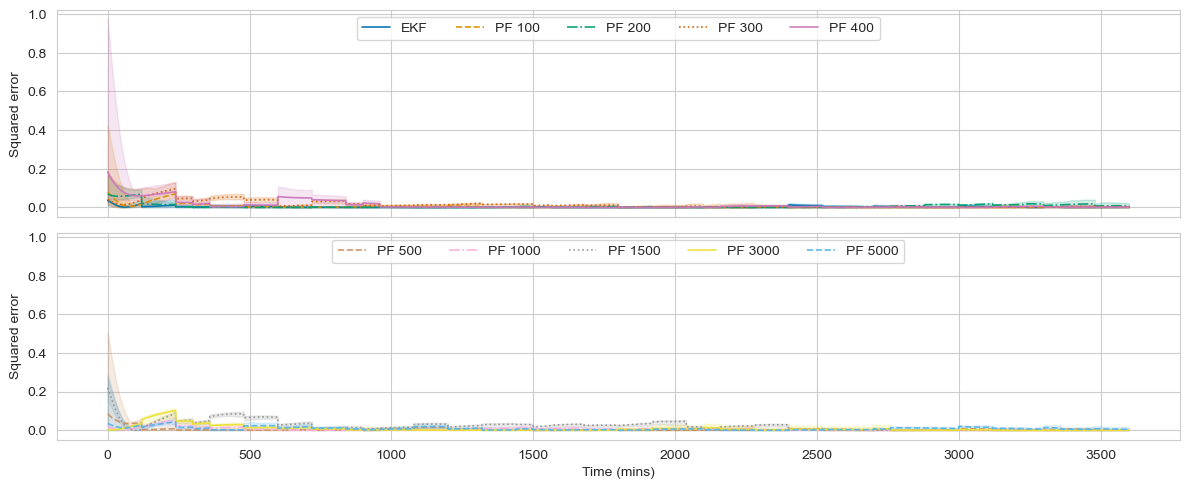

In [25]:
mean_err = np.mean(G_error, axis=1)
ci_low = np.percentile(G_error, 2.5, axis=1)
ci_high = np.percentile(G_error, 97.5, axis=1)
time = np.arange(mean_err.shape[1])
num_plots = 5 # 5 per subplot
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)

fig, ax = plt.subplots(2,1, sharex='col', sharey=True, figsize=(12,5))

for i in range(num_plots):
    ax[0].plot(time, mean_err[i], color=palette[i], linewidth=1.2, alpha=0.95, linestyle = ['-', '--', '-.', ':'][i % 4], label = filters[i])
    ax[0].fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
ax[0].set_ylabel('Squared error')
ax[0].legend(loc='upper center', ncols=num_plots)

for i in range(num_plots, 2*num_plots):
    ax[1].plot(time, mean_err[i], color=palette[i], linewidth=1.2, alpha=0.95, linestyle = ['-', '--', '-.', ':'][i % 4], label = filters[i])
    ax[1].fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
ax[1].set_xlabel('Time (mins)')
ax[1].set_ylabel('Squared error')
ax[1].legend(loc='upper center', ncols=num_plots)

fig.tight_layout()

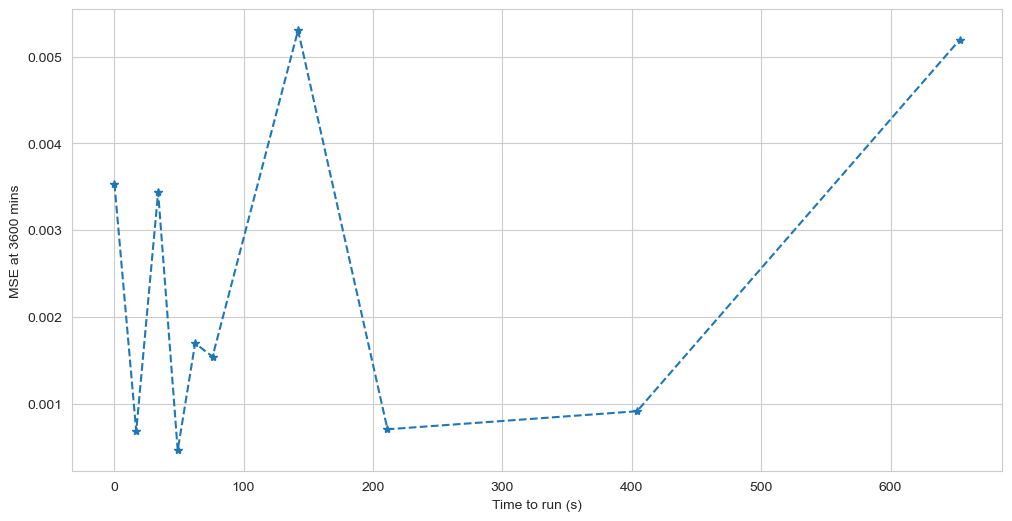

In [27]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(mean_time_run, mean_err[:,-1], linestyle='--', marker='*')
ax.set_xlabel('Time to run (s)')
ax.set_ylabel('MSE at 3600 mins');

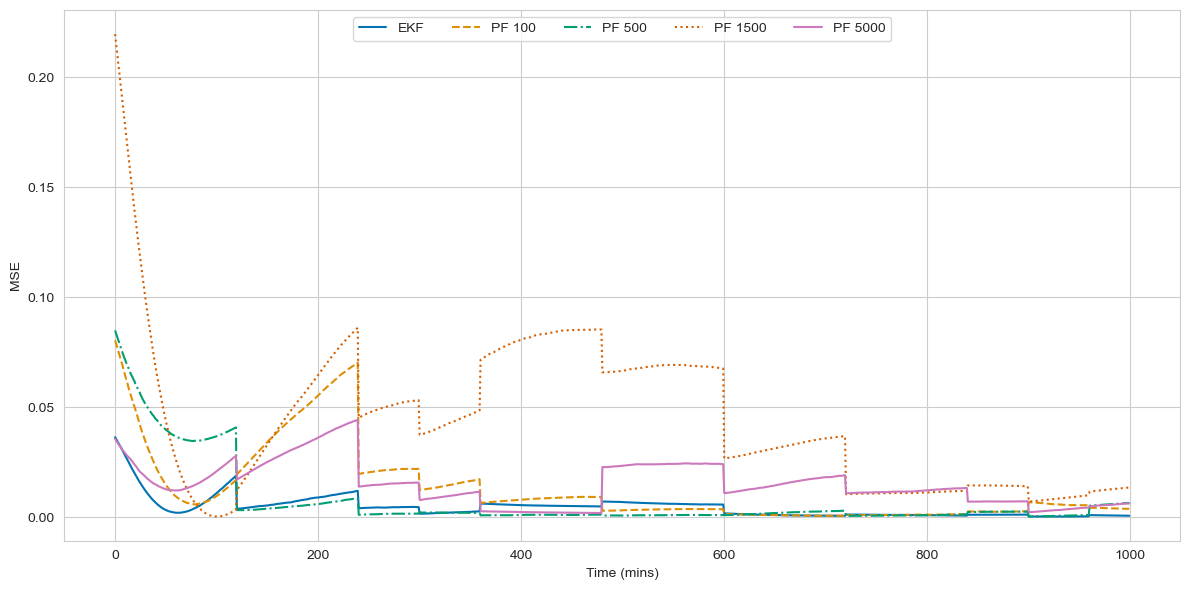

In [33]:
converge_time = 1000
chosen_filters = [0,1,5,7,9]
num_chosen = len(chosen_filters)
palette = sns.color_palette("colorblind", num_chosen)
fig, ax = plt.subplots(figsize=(12,6))

for i in range(num_chosen):
    idx = chosen_filters[i]
    ax.plot(time[:converge_time], mean_err[idx,:converge_time], color=palette[i], linestyle = ['-', '--', '-.', ':'][i % 4], label=filters[idx])
ax.set_xlabel('Time (mins)')
ax.set_ylabel('MSE')
ax.legend(ncols=num_chosen, loc='upper center')
fig.tight_layout()